In [1]:
# Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Read in data, here all protein drug combos with cluster (RFI) id
df = pd.read_csv('data/all_protein_drug_combos_clusterid.csv')

In [3]:
# Get rid of potential duplicate clusters/RFIs
df['id'] = df['protein'] + '___' + df['cluster_id'].astype(str)
df2 = df.drop_duplicates(subset='id')

In [4]:
# Count unique clusters with score > 2.197 per protein
clusters_per_protein = (
    df2.loc[df["score"] > 2.197]
      .groupby("protein")["cluster_id"]
      .nunique()
)

# Include proteins with 0 qualifying clusters
clusters_per_protein = clusters_per_protein.reindex(df2["protein"].drop_duplicates(), fill_value=0)

# Distribution: how many proteins have 0, 1, 2, 3... clusters
counts = clusters_per_protein.value_counts().sort_index()

# Force plain numeric arrays
x = counts.index.to_numpy(dtype=int)
y = counts.to_numpy(dtype=int)

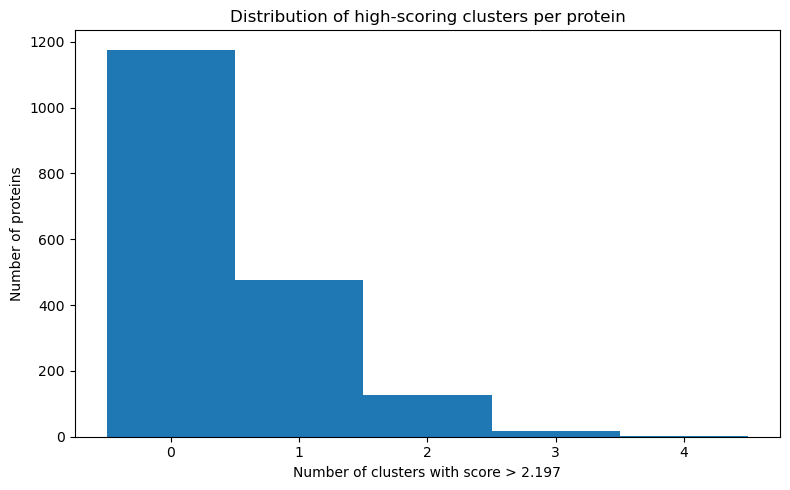

In [5]:
# Plot
plt.figure(figsize=(8, 5))
plt.bar(x, y,width=1)

# Axes labels
plt.xlabel("Number of clusters with score > 2.197")
plt.ylabel("Number of proteins")
plt.title("Distribution of high-scoring clusters per protein")
plt.xticks(x)

# Show plot
plt.tight_layout()
plt.show()